# Young Investor Behavioural Analysis
## RBC Capstone Project | Team 3

This notebook identifies and profiles young investors using demographic and behavioural data.  
It builds on the initial analysis framework and applies cleaned parquet data sources.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

## 1. Data Loading

In [ ]:
# CHANGED FROM ORIGINAL: data source switched from CSV to cleaned parquet files.
# Original code used:
#   account = pd.read_csv("BroadridgeAccount.csv")
#   role = pd.read_csv("BroadridgeAccountRole.csv")
#   party = pd.read_csv("Party.csv")
#
# Broadridge_Core_All.parquet is a pre joined table containing account, role,
# and party level fields. We extract unique accounts from it to replicate the
# original account table. Identity_All.parquet replaces Party.csv as the
# source of party level demographics.

core = pd.read_parquet("Broadridge_Core_All.parquet")
identity = pd.read_parquet("Identity_All.parquet")

# Extract account level fields (one row per account)
account_cols = [
    "PrimaryOwnerPartyId", "FinancialAccountId", "OpenDate",
    "InvestmentObjectives", "InvestmentTimeHorizon", "LiquidityNeeds",
    "RiskTolerance", "SourceofFunds"
]
account = core[account_cols].drop_duplicates(subset="FinancialAccountId")

# Extract party level fields (one row per party)
party = identity[["PartyId", "PartyAge"]].drop_duplicates(subset="PartyId")

print(f"Accounts loaded: {len(account)}")
print(f"Parties loaded: {len(party)}")

Accounts loaded: 83535
Parties loaded: 154919


## 2. Age Statistics

In [ ]:
# CHANGED FROM ORIGINAL: PartyAge in parquet is stored as string type with "NULL"
# for missing values, so we convert to numeric explicitly.
# Original code called .mean() / .median() / .std() directly on the column.

party["PartyAge_num"] = pd.to_numeric(
    party["PartyAge"].replace("NULL", pd.NA), errors="coerce"
)

average_age = party["PartyAge_num"].dropna().mean()
median_age = party["PartyAge_num"].dropna().median()
std_age = party["PartyAge_num"].dropna().std()
young_threshold = average_age - std_age

print(f"Average age of investors: {average_age:.2f}")
print(f"Median age of investors: {median_age:.2f}")
print(f"Standard deviation: {std_age:.2f}")
print(f"Young investor cutoff age (mean minus 1 std): {young_threshold:.2f}")

Average age of investors: 54.00
Median age of investors: 57.00
Standard deviation: 21.17
Young investor cutoff age (mean minus 1 std): 32.83


## 3. Identifying Young Investors

In [ ]:
account["OpenDate"] = pd.to_datetime(account["OpenDate"])

# CHANGED FROM ORIGINAL: original merged account with party on
# PrimaryOwnerPartyId == PartyId. The logic is the same here, but the
# underlying data comes from parquet tables instead of CSV.

df = pd.merge(account, party, left_on="PrimaryOwnerPartyId", right_on="PartyId")

current_year = datetime.now().year
five_years_ago = current_year - 5

print(f"Merged dataset: {len(df)} rows")
print(f"Current year: {current_year}, five year lookback starts: {five_years_ago}")

Merged dataset: 83535 rows
Current year: 2026, five year lookback starts: 2021


In [ ]:
# Condition 1: accounts opened in the last 5 years by investors whose age
# falls below one standard deviation from the mean (younger than ~33).

condition1 = (
    (df["OpenDate"].dt.year >= five_years_ago) &
    (df["PartyAge_num"] < young_threshold)
)

# Condition 2: accounts opened in the last 5 years by investors whose age
# is between the young threshold and the mean (roughly 33 to 54), AND who
# have low risk tolerance, suggesting behaviourally conservative profiles
# that may resemble newer or less experienced investors.
#
# CHANGED FROM ORIGINAL: added an upper bound of mean_age to condition2.
# The original code only had (PartyAge >= young_threshold) with no upper
# limit, which unintentionally captured investors well above the mean,
# including retirees (average age 67 in the uncapped version). Low risk
# tolerance correlates strongly with older age in this dataset (Low Risk
# group mean age = 74), so without the cap the filter pulled in elderly
# conservative investors rather than "behaviourally young" ones. Adding
# (PartyAge < mean_age) restricts condition2 to investors within one
# standard deviation of the mean, matching the stated methodology.

condition2 = (
    (df["OpenDate"].dt.year >= five_years_ago) &
    (df["PartyAge_num"] >= young_threshold) &
    (df["PartyAge_num"] < average_age) &
    (df["RiskTolerance"].isin(["Low Risk"]))
)

young_investors = df[condition1 | condition2].copy()

print(f"Number of young investors (accounts): {len(young_investors)}")
print(f"Unique parties: {young_investors['PartyId'].nunique()}")
print(f"Mean age: {young_investors['PartyAge_num'].mean():.2f}")
print(f"")
print(f"Condition 1 (age < {young_threshold:.0f}): {condition1.sum()} accounts")
print(f"Condition 2 ({young_threshold:.0f} to {average_age:.0f}, Low Risk): {condition2.sum()} accounts")

Number of young investors (accounts): 2833
Unique parties: 1774
Mean age: 28.24

Condition 1 (age < 33): 2552 accounts
Condition 2 (33 to 54, Low Risk): 281 accounts


In [ ]:
print("Age distribution of young investors:")
print(young_investors["PartyAge_num"].describe())

Age distribution of young investors:
count    2833.000000
mean       28.237204
std         6.885632
min         4.000000
25%        24.000000
50%        27.000000
75%        31.000000
max        54.000000
Name: PartyAge_num, dtype: float64


## 4. Source of Funds Classification

In [ ]:
young_investors["SourceofFunds"].value_counts()

,count
SourceofFunds,
Savings,1059
Transfer,511
Wages/Income,480
Gift/Inheritance,455
Rollover,188
NULL,52
Business/Self-employment,36
Investment Income,35
Sale of Asset,9


In [ ]:
earned_sources = [
    "Savings",
    "Wages/Income",
    "Investment Income",
    "Business/Self-employment",
    "Sale of Asset",
    "Settlement"
]

inherited_sources = [
    "Gift/Inheritance",
    "Transfer",
    "Rollover"
]

young_investors["WealthType"] = young_investors["SourceofFunds"].apply(
    lambda x: "Earned" if x in earned_sources else "Inherited"
)

young_investors["WealthType"].value_counts()

,count
WealthType,
Earned,1627
Inherited,1206


In [ ]:
print("Investment Objectives:")
print(young_investors["InvestmentObjectives"].unique())
print("")
print("Investment Time Horizon:")
print(young_investors["InvestmentTimeHorizon"].unique())
print("")
print("Liquidity Needs:")
print(young_investors["LiquidityNeeds"].unique())

Investment Objectives:
['Growth' 'Balanced Growth' 'Preservation of Principal/Income'
 'Aggressive Growth/Aggressive Income' 'Speculation']

Investment Time Horizon:
['12 years or more' '1 to 3 years' '7 to 8 years' '9 to 11 years'
 'Less than 1 year' '4 to 6 years']

Liquidity Needs:
['Less than $1,000' '$1,000 to $9,999' '$10,000 to $49,999'
 '$50,000 to $99,999' '$250,000 +' '$100,000 to $249,999']


## 5. Behavioural Analysis: Earned vs Inherited

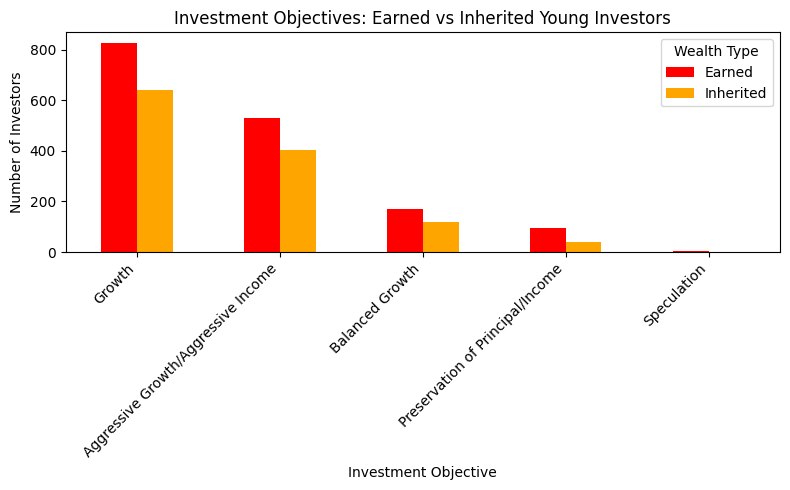

In [ ]:
objective_chart = pd.crosstab(
    young_investors["InvestmentObjectives"],
    young_investors["WealthType"]
)

objective_chart["Total"] = objective_chart.sum(axis=1)
objective_chart = objective_chart.sort_values(by="Total", ascending=False).drop(columns="Total")

objective_chart.plot(
    kind="bar",
    figsize=(8, 5),
    color=["red", "orange"]
)

plt.title("Investment Objectives: Earned vs Inherited Young Investors")
plt.ylabel("Number of Investors")
plt.xlabel("Investment Objective")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Wealth Type")
plt.tight_layout()
plt.show()

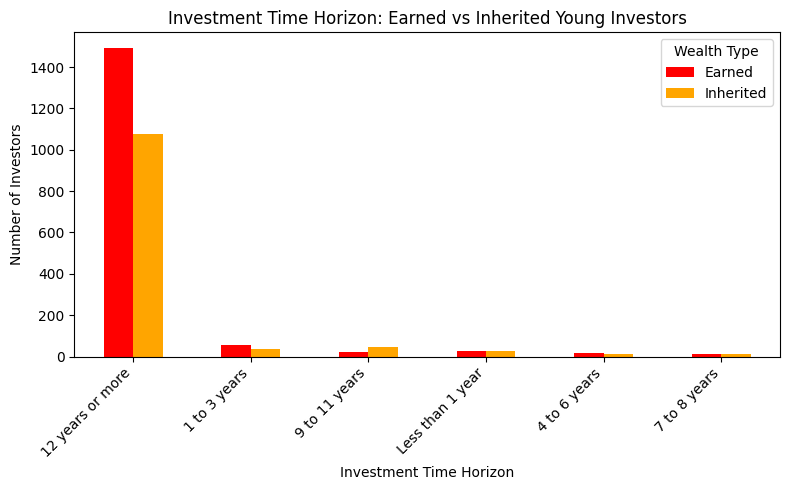

In [ ]:
horizon_chart = pd.crosstab(
    young_investors["InvestmentTimeHorizon"],
    young_investors["WealthType"]
)

horizon_chart["Total"] = horizon_chart.sum(axis=1)
horizon_chart = horizon_chart.sort_values(by="Total", ascending=False).drop(columns="Total")

horizon_chart.plot(
    kind="bar",
    figsize=(8, 5),
    color=["red", "orange"]
)

plt.title("Investment Time Horizon: Earned vs Inherited Young Investors")
plt.ylabel("Number of Investors")
plt.xlabel("Investment Time Horizon")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Wealth Type")
plt.tight_layout()
plt.show()

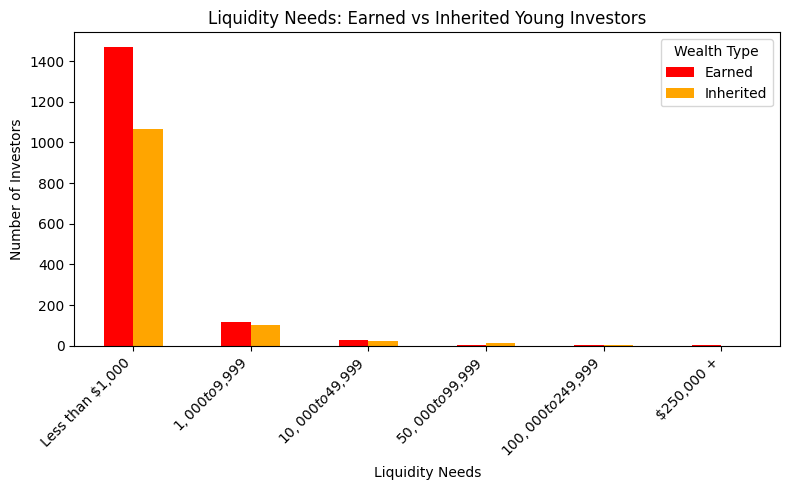

In [ ]:
liquidity_chart = pd.crosstab(
    young_investors["LiquidityNeeds"],
    young_investors["WealthType"]
)

liquidity_chart["Total"] = liquidity_chart.sum(axis=1)
liquidity_chart = liquidity_chart.sort_values(by="Total", ascending=False).drop(columns="Total")

liquidity_chart.plot(
    kind="bar",
    figsize=(8, 5),
    color=["red", "orange"]
)

plt.title("Liquidity Needs: Earned vs Inherited Young Investors")
plt.ylabel("Number of Investors")
plt.xlabel("Liquidity Needs")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Wealth Type")
plt.tight_layout()
plt.show()

## 6. Supplementary Analysis

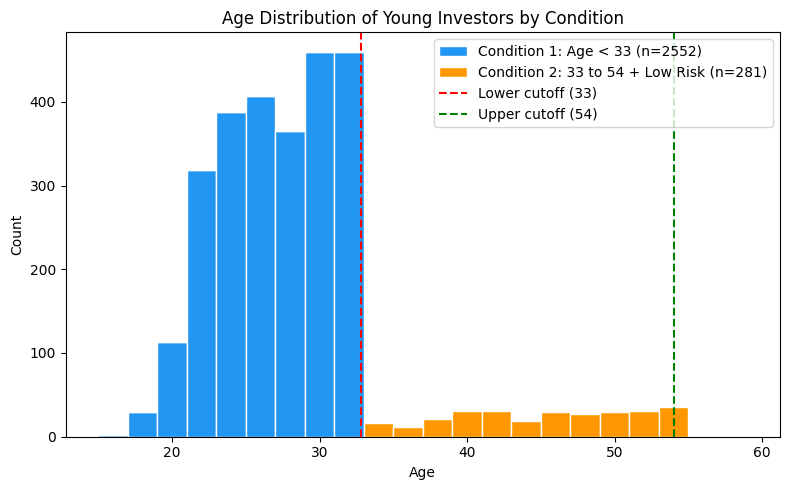

Condition 1 mean age: 26.4
Condition 2 mean age: 44.9


In [ ]:
# NEW: visualize the age distribution by condition to confirm the two
# sub populations are reasonable after the condition2 correction.

young_investors["Segment"] = "Condition 2 (33 to 54, Low Risk)"
young_investors.loc[
    young_investors["PartyAge_num"] < young_threshold, "Segment"
] = "Condition 1 (Age < 33)"

c1_ages = young_investors.loc[
    young_investors["Segment"] == "Condition 1 (Age < 33)", "PartyAge_num"
].dropna()
c2_ages = young_investors.loc[
    young_investors["Segment"] == "Condition 2 (33 to 54, Low Risk)", "PartyAge_num"
].dropna()

plt.figure(figsize=(8, 5))
plt.hist(
    [c1_ages, c2_ages],
    bins=range(15, 60, 2),
    color=["#2196F3", "#FF9800"],
    label=[f"Condition 1: Age < 33 (n={len(c1_ages)})",
           f"Condition 2: 33 to 54 + Low Risk (n={len(c2_ages)})"],
    stacked=True,
    edgecolor="white"
)
plt.axvline(x=young_threshold, color="red", linestyle="--",
            label=f"Lower cutoff ({young_threshold:.0f})")
plt.axvline(x=average_age, color="green", linestyle="--",
            label=f"Upper cutoff ({average_age:.0f})")
plt.title("Age Distribution of Young Investors by Condition")
plt.xlabel("Age")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Condition 1 mean age: {c1_ages.mean():.1f}")
print(f"Condition 2 mean age: {c2_ages.mean():.1f}")

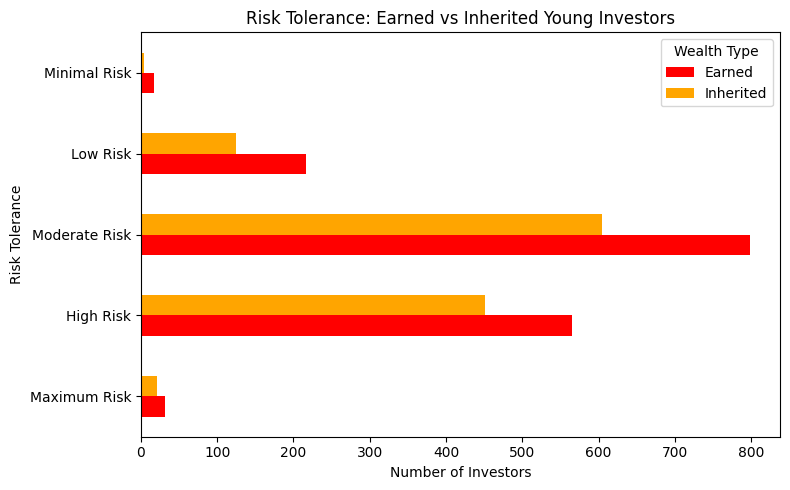

Risk Tolerance by Wealth Type:
WealthType     Earned  Inherited   All
RiskTolerance                         
High Risk         565        451  1016
Low Risk          216        125   341
Maximum Risk       31         21    52
Minimal Risk       17          4    21
Moderate Risk     798        605  1403
All              1627       1206  2833


In [ ]:
# NEW: risk tolerance breakdown by wealth type shows how earned vs
# inherited young investors differ in risk appetite.

risk_chart = pd.crosstab(
    young_investors["RiskTolerance"],
    young_investors["WealthType"]
)

risk_order = ["Maximum Risk", "High Risk", "Moderate Risk", "Low Risk", "Minimal Risk"]
risk_chart = risk_chart.reindex([r for r in risk_order if r in risk_chart.index])

risk_chart.plot(
    kind="barh",
    figsize=(8, 5),
    color=["red", "orange"]
)

plt.title("Risk Tolerance: Earned vs Inherited Young Investors")
plt.xlabel("Number of Investors")
plt.ylabel("Risk Tolerance")
plt.legend(title="Wealth Type")
plt.tight_layout()
plt.show()

print("Risk Tolerance by Wealth Type:")
print(pd.crosstab(
    young_investors["RiskTolerance"],
    young_investors["WealthType"],
    margins=True
))

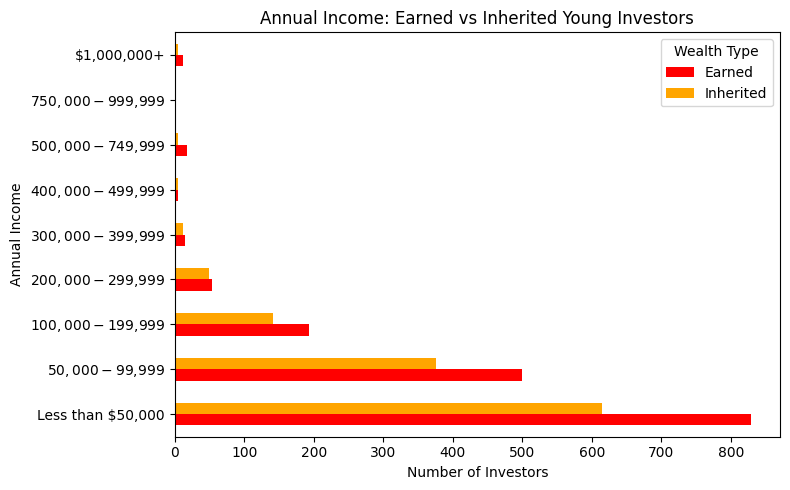

Annual Income by Wealth Type:
WealthType           Earned  Inherited   All
AnnualIncome                                
$1,000,000+              12          4    16
$100,000 - $199,999     193        141   334
$200,000 - $299,999      53         49   102
$300,000 - $399,999      14         12    26
$400,000 - $499,999       5          5    10
$50,000 - $99,999       500        376   876
$500,000 - $749,999      18          4    22
$750,000 - $999,999       2          1     3
Less than $50,000       829        614  1443
All                    1627       1206  2833


In [ ]:
# NEW: annual income distribution by wealth type. Income data is pulled
# from Identity_All (party level) since the account table does not carry
# this field directly.

identity_demo = identity[["PartyId", "AnnualIncome", "TotalNetWorth"]].drop_duplicates(
    subset="PartyId"
)
young_with_demo = young_investors.merge(identity_demo, on="PartyId", how="left")

income_order = [
    "Less than $50,000",
    "$50,000 - $99,999",
    "$100,000 - $199,999",
    "$200,000 - $299,999",
    "$300,000 - $399,999",
    "$400,000 - $499,999",
    "$500,000 - $749,999",
    "$750,000 - $999,999",
    "$1,000,000+"
]

inc_chart = pd.crosstab(young_with_demo["AnnualIncome"], young_with_demo["WealthType"])
inc_chart = inc_chart.drop("NULL", errors="ignore")
inc_chart = inc_chart.reindex([i for i in income_order if i in inc_chart.index])

inc_chart.plot(
    kind="barh",
    figsize=(8, 5),
    color=["red", "orange"]
)

plt.title("Annual Income: Earned vs Inherited Young Investors")
plt.xlabel("Number of Investors")
plt.ylabel("Annual Income")
plt.legend(title="Wealth Type")
plt.tight_layout()
plt.show()

print("Annual Income by Wealth Type:")
print(pd.crosstab(
    young_with_demo["AnnualIncome"],
    young_with_demo["WealthType"],
    margins=True
).drop("NULL", errors="ignore"))

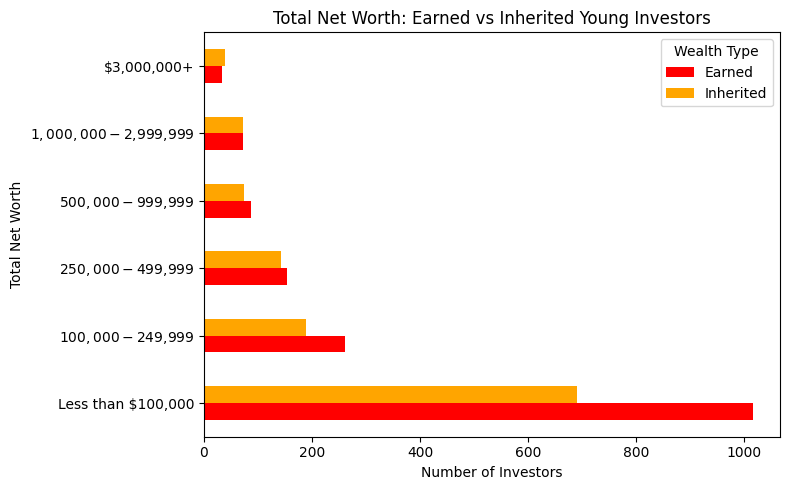

Total Net Worth by Wealth Type:
WealthType               Earned  Inherited   All
TotalNetWorth                                   
$1,000,000 - $2,999,999      73         72   145
$100,000 - $249,999         262        188   450
$250,000 - $499,999         154        142   296
$3,000,000+                  34         39    73
$500,000 - $999,999          87         74   161
Less than $100,000         1016        691  1707
All                        1627       1206  2833


In [ ]:
# NEW: total net worth distribution by wealth type helps identify whether
# inherited wealth young investors hold significantly more assets.

nw_order = [
    "Less than $100,000",
    "$100,000 - $249,999",
    "$250,000 - $499,999",
    "$500,000 - $999,999",
    "$1,000,000 - $2,999,999",
    "$3,000,000+"
]

nw_chart = pd.crosstab(young_with_demo["TotalNetWorth"], young_with_demo["WealthType"])
nw_chart = nw_chart.drop("NULL", errors="ignore")
nw_chart = nw_chart.reindex([n for n in nw_order if n in nw_chart.index])

nw_chart.plot(
    kind="barh",
    figsize=(8, 5),
    color=["red", "orange"]
)

plt.title("Total Net Worth: Earned vs Inherited Young Investors")
plt.xlabel("Number of Investors")
plt.ylabel("Total Net Worth")
plt.legend(title="Wealth Type")
plt.tight_layout()
plt.show()

print("Total Net Worth by Wealth Type:")
print(pd.crosstab(
    young_with_demo["TotalNetWorth"],
    young_with_demo["WealthType"],
    margins=True
).drop("NULL", errors="ignore"))